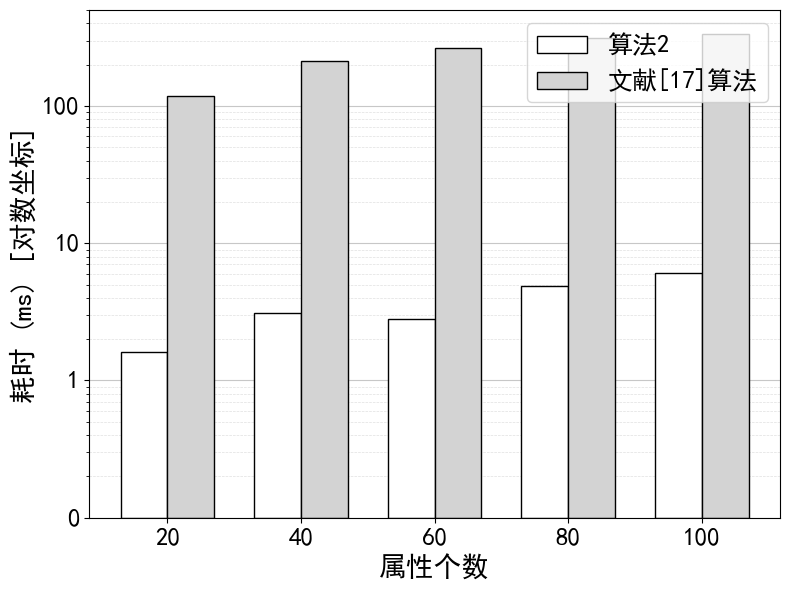

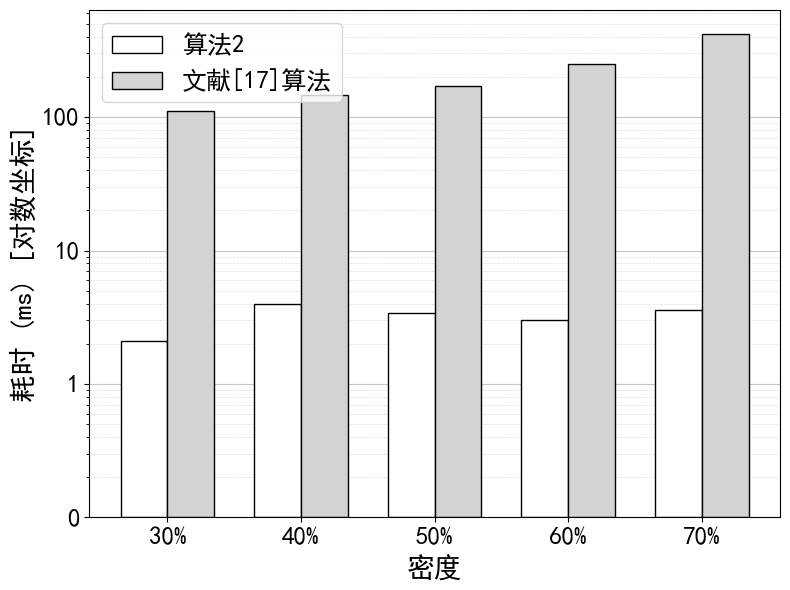

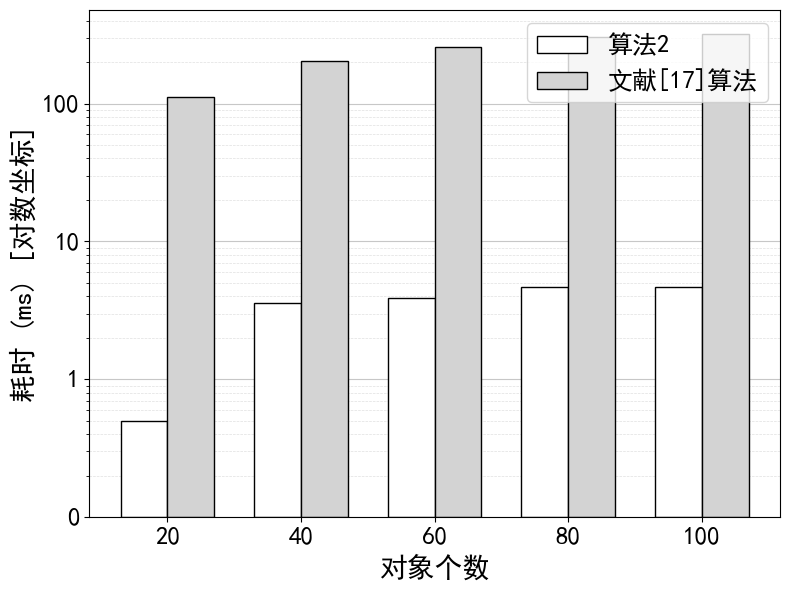

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
import re
from matplotlib.ticker import ScalarFormatter  # 新增：用于格式化对数坐标轴的数字显示

# 设置支持中文的字体，避免标签显示为方块
plt.rcParams['font.sans-serif'] = ['SimHei', 'Songti SC', 'Arial Unicode MS'] # 适配 Windows/Mac
plt.rcParams['axes.unicode_minus'] = False # 正常显示负号

# ================= 全局调大字号设置 =================
plt.rcParams['axes.labelsize'] = 20  # 坐标轴标签字号 耗时 (ms), 属性个数
plt.rcParams['xtick.labelsize'] = 18 # X轴坐标值/刻度字号 "30%", "40%"
plt.rcParams['ytick.labelsize'] = 18 # Y轴坐标值/刻度字号
plt.rcParams['legend.fontsize'] = 18 # 图例字号 本文算法
# ==========================================================

def read_and_average(filepath):
    """
    读取文件并计算两列的平均值
    """
    col1, col2 = [], []
    if os.path.exists(filepath):
        with open(filepath, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                # 过滤空行
                if line:
                    parts = line.split(',')
                    if len(parts) == 2:
                        col1.append(float(parts[0]))
                        col2.append(float(parts[1]))
    # 如果文件有数据，则返回平均值；否则返回(0,0)
    if col1 and col2:
        return np.mean(col1), np.mean(col2)
    return 0, 0

# 路径配置
base_dir = '../data/input2'
output_dir = '../data/output3'

# 1. 使用正则表达式从文件名中动态获取 X 轴坐标
attr_x, obj_x, dense_x = [], [], []

if os.path.exists(base_dir):
    for filename in os.listdir(base_dir):
        # 匹配 attr_数字.txt
        match_attr = re.match(r'attr_(\d+)\.txt', filename)
        if match_attr:
            attr_x.append(int(match_attr.group(1)))
            
        # 匹配 obj_数字.txt
        match_obj = re.match(r'obj_(\d+)\.txt', filename)
        if match_obj:
            obj_x.append(int(match_obj.group(1)))
            
        # 匹配 dense_浮点数.txt
        match_dense = re.match(r'dense_([\d.]+)\.txt', filename)
        if match_dense:
            dense_x.append(float(match_dense.group(1)))

# 对提取的数值进行排序，确保横坐标按从小到大的顺序排列
attr_x.sort()
obj_x.sort()
dense_x.sort()

# 确保输出文件夹存在，如果不存在则自动创建
os.makedirs(output_dir, exist_ok=True)

# 获取各类别的均值
attr_means = [read_and_average(f'{base_dir}/attr_{x}.txt') for x in attr_x]
obj_means = [read_and_average(f'{base_dir}/obj_{x}.txt') for x in obj_x]
dense_means = [read_and_average(f'{base_dir}/dense_{x}.txt') for x in dense_x]

# 解包均值数据
attr_inc, attr_full = zip(*attr_means) if attr_means else ((), ())
obj_inc, obj_full = zip(*obj_means) if obj_means else ((), ())
dense_inc, dense_full = zip(*dense_means) if dense_means else ((), ())

width = 0.35 # 柱子的宽度

def plot_and_save_double_bars(x_labels, inc_data, full_data, xlabel, output_filename):
    """
    绘制单独的双柱状图并保存到指定路径（对数坐标+辅助视觉特征）
    """
    fig, ax = plt.subplots(figsize=(8, 6))
    x = np.arange(len(x_labels))
    
    # 增量算法柱：深灰色背景
    ax.bar(x - width/2, inc_data, width, label='算法2', 
           color='white', edgecolor='black', bottom=0.1)
    
    # 全量算法柱：浅灰色背景
    ax.bar(x + width/2, full_data, width, label='文献[17]算法', 
           color='lightgray', edgecolor='black', bottom=0.1)
    
    # 设置为对数坐标轴
    ax.set_yscale('log')
    
    # 格式化Y轴显示为常规数字: 1, 10, 100
    formatter = ScalarFormatter()
    formatter.set_scientific(False)
    ax.yaxis.set_major_formatter(formatter)
    
    # 强制Y轴下限，保证柱子能够画出
    ax.set_ylim(bottom=0.1)

    # 【修改点 1】更改 Y 轴标签，明确提示读者这是对数坐标系
    ax.set_ylabel('耗时 (ms) [对数坐标]')
    ax.set_xlabel(xlabel)
    
    # 【修改点 2】开启 Y 轴的主网格线和次网格线，这是体现对数坐标最直观的视觉特征！
    # 主刻度网格线（1, 10, 100 处）用实线
    ax.grid(axis='y', which='major', linestyle='-', linewidth=0.8, alpha=0.7)
    # 次刻度网格线（2,3,4... 20,30,40... 处）用虚线，展现由疏到密的渐变感
    ax.grid(axis='y', which='minor', linestyle='--', linewidth=0.5, alpha=0.4)
    # 把网格线置于柱子底层，防止遮挡数据
    ax.set_axisbelow(True)

    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.legend()

    # 自动调整子图间距
    plt.tight_layout()
    
    # 拼接完整的保存路径并保存图片
    save_path = os.path.join(output_dir, output_filename)
    plt.savefig(save_path, dpi=800, bbox_inches='tight')
    
    # 在Jupyter中展示当前图表
    plt.show()
    
    # 关闭画布
    plt.close(fig)

# 1. 绘制并保存 attr 柱状图
if attr_x:
    plot_and_save_double_bars(attr_x, attr_inc, attr_full, '属性个数', 'attr_time_comparison.png')

# 2. 绘制并保存 dense 柱状图 (横坐标转换为百分比显示)
if dense_x:
    dense_labels = ['30%', '40%', '50%', '60%', '70%']
    plot_and_save_double_bars(dense_labels, dense_inc, dense_full, '密度', 'dense_time_comparison.png')

# 3. 绘制并保存 obj 柱状图
if obj_x:
    plot_and_save_double_bars(obj_x, obj_inc, obj_full, '对象个数', 'obj_time_comparison.png')